In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import os.path
from pathlib import Path
import albumentations as A
import cv2
import scipy
import scipy.io
from scipy.ndimage import gaussian_filter
import keras
from keras.optimizers import RMSprop,Adam,Optimizer,Optimizer, SGD
from keras.callbacks import ModelCheckpoint
from keras import metrics
import tensorflow as tf
import h5py
from sklearn.model_selection import train_test_split
import random
from PIL import Image
from keras.layers import Conv2D, MaxPooling2D, Concatenate, Input
from keras.models import Model
from keras.models import load_model
from math import ceil
from keras.callbacks import Callback, ModelCheckpoint
import csv

/opt/conda/lib/python3.10/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.2 (you have 1.4.17). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [24]:
aug_train = A.Compose([
    A.Resize(768, 1024),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(),
    A.Normalize((0.5), (0.5)),
], keypoint_params=A.KeypointParams(format='xy', angle_in_degrees=False))

aug_val = A.Compose([
    A.Resize(768 , 1024),
    A.Normalize((0.5), (0.5)),
], keypoint_params=A.KeypointParams(format='xy', angle_in_degrees=False))

aug_val_test = A.Compose([
    A.Normalize((0.5), (0.5))
], keypoint_params=A.KeypointParams(format='xy', angle_in_degrees=False))


In [25]:
train_A = [p.path for p in os.scandir('/kaggle/input/shanghaitech/ShanghaiTech/part_A/train_data/images')]
valid_A = [p.path for p in os.scandir('/kaggle/input/shanghaitech/ShanghaiTech/part_A/test_data/images')]

# Set a seed for reproducibility
random.seed(42)  
random.shuffle(valid_A)
# Calculate the split index
split_index = ceil(len(valid_A) * 0.9)

# Split the data
valid_A_split = valid_A[:split_index]  # 90% for validation
test_A_split = valid_A[split_index:]  # 10% for testing

train_B = [p.path for p in os.scandir('/kaggle/input/shanghaitech/ShanghaiTech/part_B/train_data/images')]
valid_B = [p.path for p in os.scandir('/kaggle/input/shanghaitech/ShanghaiTech/part_B/test_data/images')]

# Set a seed for reproducibility
random.seed(42)  
random.shuffle(valid_B)
# Calculate the split index
split_index = ceil(len(valid_B) * 0.9)

# Split the data
valid_B_split = valid_B[:split_index]  # 90% for validation
test_B_split = valid_B[split_index:]  # 10% for testing

# Create a list of file paths for images in the Nol Km directory that end with .png extension
NOL_KM = [p.path for p in os.scandir('/kaggle/input/cctv-nol-km-100-images') if p.name.endswith('.png')]

# Set a seed for reproducibility
random.seed(42)  
random.shuffle(NOL_KM)

In [30]:
len(train_A), len(valid_A_split), len(test_A_split)

(300, 164, 18)

In [31]:
len(train_B), len(valid_B_split), len(test_B_split)

(400, 285, 31)

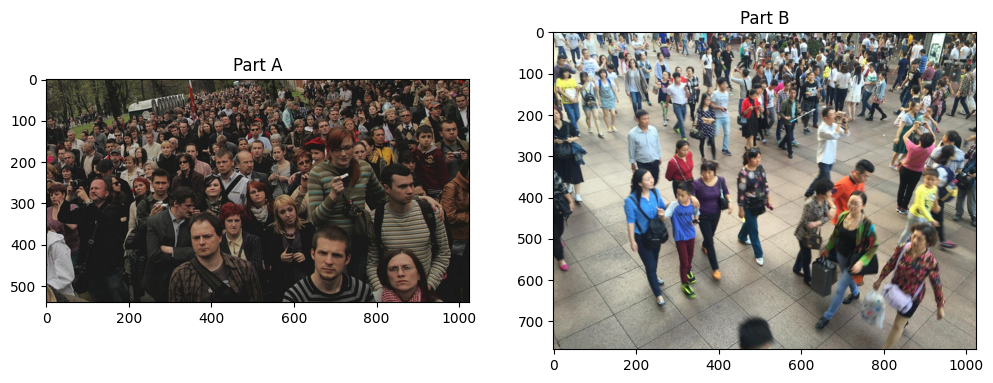

In [28]:
im = cv2.imread(train_A[0], cv2.IMREAD_COLOR)
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
im2 = cv2.imread(train_B[0], cv2.IMREAD_COLOR)
im2 = cv2.cvtColor(im2, cv2.COLOR_BGR2RGB)

f, axarr = plt.subplots(1, 2, figsize=(12, 12))
axarr[0].imshow(im, cmap='gray')
axarr[0].title.set_text('Part A')
axarr[1].imshow(im2, cmap='gray')
axarr[1].title.set_text('Part B')

Text(0.5, 1.0, 'Nol Km')

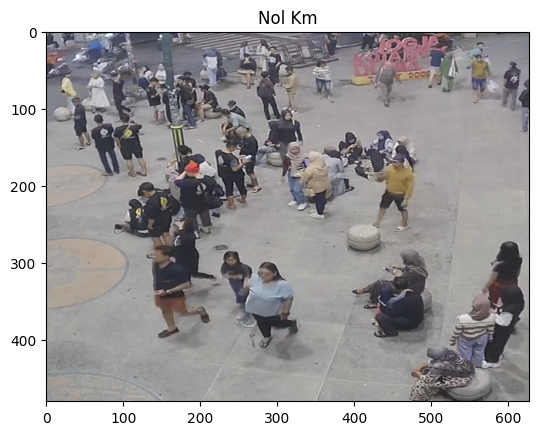

In [8]:
im = cv2.imread(NOL_KM[0], cv2.IMREAD_COLOR)
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

plt.imshow(im, cmap='gray')
plt.title('Nol Km')

In [23]:
# Initialize an empty list to store the number of people in each image
sum_img = []

# Combine the training and validation datasets into one list (combined_A)
combined_A = train_A + valid_A

# Initialize variables to track the maximum and minimum values
max_people_A = float('-inf')
min_people_A = float('inf')

# Loop through each item in the combined dataset
for count in range(len(combined_A)):
  # Get the file path for the current image
  tmp_file =combined_A[count]
    
  # Load the corresponding ground truth .mat file
  m = scipy.io.loadmat(tmp_file.replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))
  
  # Extract the list of people density map data (stored in the 'image_info' field)
  ps = m['image_info'][0][0][0][0][0]
    
  # Get the length of the list (which represents the number of people in the image)  
  dm = len(ps)

  # Update maximum and minimum values  
  if dm > max_people_A:
      max_people_A = dm
  if dm < min_people_A:
      min_people_A = dm
    
  # Append the number of people (dm) to the sum_img list  
  sum_img.append(dm)
    
# Calculate the mean number of people in the images by dividing the total by the number of images
meanA = sum(sum_img) / len(sum_img)

# Print results
print("Total images in Part B: ", len(combined_A))
print("Mean number of people in part A:", meanA)
print("Maximum number of people in an part A image:", max_people_A)
print("Minimum number of people in an part A image:", min_people_A)


Total images in Part B:  482
Mean number of people in part A: 500.57053941908714
Maximum number of people in an part A image: 3138
Minimum number of people in an part A image: 33


In [32]:
# Initialize an empty list to store the number of people in each image
sum_img = []

# Combine the training and validation datasets into one list (combined_A)
combined_B = train_B + valid_B

# Initialize variables to track the maximum and minimum values
max_people_B = float('-inf')
min_people_B = float('inf')

# Loop through each item in the combined dataset
for count in range (len(combined_B)):
  # Get the file path for the current image  
  tmp_file =combined_B[count]

  # Load the corresponding ground truth .mat file 
  m = scipy.io.loadmat(tmp_file.replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))

  # Extract the list of people density map data (stored in the 'image_info' field)  
  ps = m['image_info'][0][0][0][0][0]

  # Get the length of the list (which represents the number of people in the image)  
  dm = len(ps)
    
  # Update maximum and minimum values  
  if dm > max_people_B:
      max_people_B = dm
  if dm < min_people_B:
      min_people_B = dm

  # Append the number of people (dm) to the sum_img list  
  sum_img.append(dm)

# Calculate the mean number of people in the images by dividing the total by the number of images
meanB = sum(sum_img) / len(sum_img)

# Print results
print("Total images in Part B: ", len(combined_B))
print("Mean number of people in part B:", meanB)
print("Maximum number of people in an part B image:", max_people_B)
print("Minimum number of people in an part B image:", min_people_B)


Total images in Part B:  716
Mean number of people in part B: 123.28491620111731
Maximum number of people in an part B image: 576
Minimum number of people in an part B image: 9


In [33]:
# Initialize an empty list to store the number of people in each image
sum_img = []

# Initialize variables to track the maximum and minimum values
max_people_NOL_KM = float('-inf')
min_people_NOL_KM = float('inf')

# Loop through each item in the combined dataset
for count in range(len(NOL_KM)):
  # Get the file path for the current image  
  tmp_file =NOL_KM[count]  

  # Load the corresponding ground truth .mat file  
  m = scipy.io.loadmat(tmp_file.replace('.png', '.mat'))

  # Extract the list of people density map data (stored in the 'annPoints' field)  
  ps = m["coordinates"]

  # Get the length of the list (which represents the number of people in the image)  
  dm = len(ps)
    
  # Update maximum and minimum values  
  if dm > max_people_NOL_KM:
      max_people_NOL_KM = dm
  if dm < min_people_NOL_KM:
      min_people_NOL_KM = dm

  # Append the number of people (dm) to the sum_img list  
  sum_img.append(dm)

# Calculate the mean number of people in the images by dividing the total by the number of images
meanNOLKM = sum(sum_img) / len(sum_img)

# Print results
print("Total images in Nol Km Dataset: ", len(NOL_KM))
print("Mean number of people in NOL KM:", meanNOLKM)
print("Maximum number of people in an NOL KM image:", max_people_NOL_KM)
print("Minimum number of people in an NOL KM image:", min_people_NOL_KM)

Total images in Nol Km Dataset:  100
Mean number of people in NOL KM: 30.05
Maximum number of people in an NOL KM image: 132
Minimum number of people in an NOL KM image: 6


In [34]:
# Load the corresponding ground truth .mat file for the first image in the train_A list
m = scipy.io.loadmat(train_A[0].replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))

# Print the loaded .mat data
print(m)

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Fri Nov 18 20:06:08 2016', '__version__': '1.0', '__globals__': [], 'image_info': array([[array([[(array([[  25.99681609,  280.90289066],
                       [  49.01929898,  234.85792487],
                       [   6.97824326,  234.85792487],
                       [  14.9860634 ,  100.72693758],
                       [  64.03396174,  134.76017316],
                       [  91.0603547 ,  138.76408323],
                       [ 121.08968021,  123.74942047],
                       [ 113.08186008,  148.7738584 ],
                       [ 104.07306242,  165.79047619],
                       [  56.0261416 ,  162.78754364],
                       [  38.00854629,  183.8080715 ],
                       [  55.02516408,  197.82175674],
                       [ 154.12193828,  164.78949867],
                       [ 170.13757855,  187.81198157],
                       [ 147.11509566,  225.84912722],
                       

In [35]:
# Load the corresponding ground truth .mat file for the first image in the train_A list
m = scipy.io.loadmat(train_A[0].replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))

# Extract the people density map data from the 'image_info' field in the .mat file
# This 'ps' variable contains the list of (x, y) coordinates representing people in the image
ps = m['image_info'][0][0][0][0][0]

# Print the extracted people density map data
print(ps)

[[  25.99681609  280.90289066]
 [  49.01929898  234.85792487]
 [   6.97824326  234.85792487]
 [  14.9860634   100.72693758]
 [  64.03396174  134.76017316]
 [  91.0603547   138.76408323]
 [ 121.08968021  123.74942047]
 [ 113.08186008  148.7738584 ]
 [ 104.07306242  165.79047619]
 [  56.0261416   162.78754364]
 [  38.00854629  183.8080715 ]
 [  55.02516408  197.82175674]
 [ 154.12193828  164.78949867]
 [ 170.13757855  187.81198157]
 [ 147.11509566  225.84912722]
 [ 168.13562352  258.88138528]
 [ 129.09750035  275.89800307]
 [ 225.19134199  266.88920542]
 [ 251.21675744  222.84619467]
 [ 286.25097053  263.88627287]
 [ 195.16201648  206.83055439]
 [ 223.18938696  180.80513895]
 [ 293.25781315  171.79634129]
 [ 310.27443095  155.78070102]
 [ 354.3174417   176.80122888]
 [ 339.30277894  205.82957687]
 [ 336.29984639  312.93417121]
 [ 384.34676721  385.00455244]
 [ 454.41519341  352.97327189]
 [ 402.36436252  261.88431783]
 [ 429.39075548  209.83348694]
 [ 488.44842899  206.83055439]
 [ 517.4

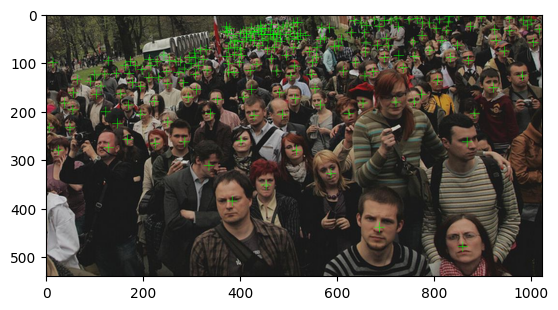

In [36]:
# Read the image using OpenCV in color mode (BGR format by default)
im = cv2.imread(train_A[0], cv2.IMREAD_COLOR)

# Convert the image from BGR to RGB color format for correct display in matplotlib
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Load the corresponding ground truth .mat file for the first image in the train_A list
m = scipy.io.loadmat(train_A[0].replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))

# Extract the people density map data from the 'image_info' field in the .mat file
# This 'ps' variable contains the list of (x, y) coordinates representing people in the image
ps = m['image_info'][0][0][0][0][0]

# Loop through each (x, y) coordinate in the people density map (ps)
# These coordinates represent the positions of people in the image
for x, y in ps:
    # Convert x and y coordinates to integers (since pixel positions must be integer values)
    x = int(x)
    y = int(y)

    # Draw a marker on the image at the (x, y) position with green color (0, 255, 0)
    # The marker will indicate the location of a person in the image
    cv2.drawMarker(im, (x, y), (0, 255, 0))
    
plt.imshow(im)

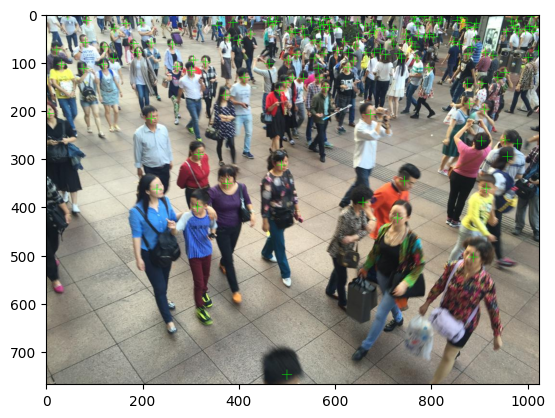

In [37]:
# Read the image using OpenCV in color mode (BGR format by default)
im = cv2.imread(train_B[0], cv2.IMREAD_COLOR)

# Convert the image from BGR to RGB color format for correct display in matplotlib
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Load the corresponding ground truth .mat file for the first image in the train_A list
m = scipy.io.loadmat(train_B[0].replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))

# Extract the people density map data from the 'image_info' field in the .mat file
# This 'ps' variable contains the list of (x, y) coordinates representing people in the image
ps = m['image_info'][0][0][0][0][0]

# Loop through each (x, y) coordinate in the people density map (ps)
# These coordinates represent the positions of people in the image
for x, y in ps:
    # Convert x and y coordinates to integers (since pixel positions must be integer values)
    x = int(x)
    y = int(y)

    # Draw a marker on the image at the (x, y) position with green color (0, 255, 0)
    # The marker will indicate the location of a person in the image
    cv2.drawMarker(im, (x, y), (0, 255, 0))
    
plt.imshow(im)

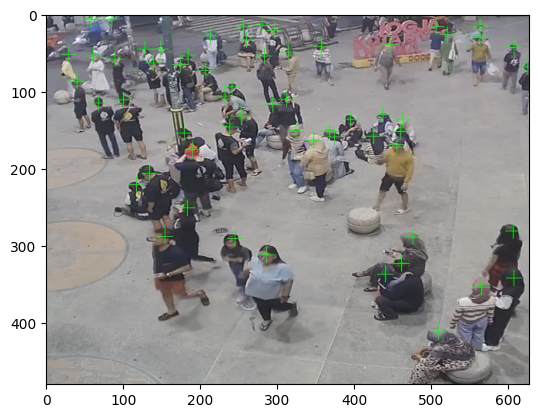

In [38]:
# Read the image using OpenCV in color mode (BGR format by default)
im = cv2.imread(NOL_KM[0], cv2.IMREAD_COLOR)

# Convert the image from BGR to RGB color format for correct display in matplotlib
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Load the corresponding ground truth .mat file for the first image in the train_A list
m = scipy.io.loadmat(NOL_KM[0].replace('.png', '.mat'))

# Extract the people density map data from the 'image_info' field in the .mat file
# This 'ps' variable contains the list of (x, y) coordinates representing people in the image
ps = m['coordinates']

# Loop through each (x, y) coordinate in the people density map (ps)
# These coordinates represent the positions of people in the image
for x, y in ps:
    # Convert x and y coordinates to integers (since pixel positions must be integer values)
    x = int(x)
    y = int(y)

    # Draw a marker on the image at the (x, y) position with green color (0, 255, 0)
    # The marker will indicate the location of a person in the image
    cv2.drawMarker(im, (x, y), (0, 255, 0))
    
plt.imshow(im)

In [39]:
class DatasetA(keras.utils.Sequence):
    def __init__(self, files, aug):
        self.files = files
        self.aug = aug
        
    def __len__(self):
        return len(self.files)
        
    def __getitem__(self, idx):
        fn = self.files[idx]

        im = cv2.imread(fn, cv2.IMREAD_COLOR)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

        m = scipy.io.loadmat(fn.replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))
        ps = m['image_info'][0][0][0][0][0]

        rst = self.aug(image=im, keypoints=ps)
        im = rst['image']
        ps = rst['keypoints']

        dm = np.zeros((im.shape[0], im.shape[1]), dtype=np.float32)
        for x, y in ps:
            x = int(x)
            y = int(y)
            dm[y, x] = 1

        sigma = 4
        dm = gaussian_filter(dm, sigma=sigma, truncate=4*sigma)

        ht = im.shape[0]
        wd = im.shape[1]

        ht_1 = int((ht // 4))
        wd_1 = int((wd // 4))

        dm = cv2.resize(dm, (wd_1, ht_1), interpolation=cv2.INTER_LINEAR)
        dm *= 16

        return im, dm

In [40]:
class DatasetB(keras.utils.Sequence):
    def __init__(self, files, aug):
        self.files = files
        self.aug = aug
        
    def __len__(self):
        return len(self.files)
        
    def __getitem__(self, idx):
        fn = self.files[idx]

        im = cv2.imread(fn, cv2.IMREAD_COLOR)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

        m = scipy.io.loadmat(fn.replace('images', 'ground-truth').replace('IMG', 'GT_IMG').replace('.jpg', '.mat'))
        ps = m['image_info'][0][0][0][0][0]

        rst = self.aug(image=im, keypoints=ps)
        im = rst['image']
        ps = rst['keypoints']

        dm = np.zeros((im.shape[0], im.shape[1]), dtype=np.float32)
        for x, y in ps:
            x = int(x)
            y = int(y)
            dm[y, x] = 1

        sigma = 15
        dm = gaussian_filter(dm, sigma=sigma)

        ht = im.shape[0]
        wd = im.shape[1]

        ht_1 = int((ht // 4))
        wd_1 = int((wd // 4))

        dm = cv2.resize(dm, (wd_1, ht_1), interpolation=cv2.INTER_LINEAR)
        dm *= 16

        return im, dm

In [33]:
def clip_keypoints(keypoints, img_width, img_height):
    keypoints[:, 0] = np.clip(keypoints[:, 0], 0, img_width - 1)  # Clip x-coordinate
    keypoints[:, 1] = np.clip(keypoints[:, 1], 0, img_height - 1)  # Clip y-coordinate
    return keypoints


class UCF_CC_50(keras.utils.Sequence):
    def __init__(self, files, aug):
        self.files = files
        self.aug = aug

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fn = self.files[idx]

        im = cv2.imread(fn, cv2.IMREAD_COLOR)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

        m = scipy.io.loadmat(fn.replace('UCF_CC_50 (img only)', 'UCF_CC_50 (GT only)').replace('.jpg', '_ann.mat'))

        ps = m["annPoints"]
        ps = np.array(ps)
        ps = clip_keypoints(ps, img_width=im.shape[1], img_height=im.shape[0])  # Ensure they stay within bounds
        
        rst = self.aug(image=im, keypoints=ps)
        im = rst["image"]
        ps = rst['keypoints']

        dm = np.zeros((im.shape[0], im.shape[1]), dtype=np.float32)
        for x, y in ps:
            x = int(x)
            y = int(y)
            dm[y, x] = 1

        sigma = 4
        dm = gaussian_filter(dm, sigma=sigma, truncate=4*sigma)

        ht = im.shape[0]
        wd = im.shape[1]

        ht_1 = int((ht // 4))
        wd_1 = int((wd // 4))

        dm = cv2.resize(dm, (wd_1, ht_1), interpolation=cv2.INTER_LINEAR)
        dm *= 16
        
        return im, dm

In [41]:
class NOLKM(keras.utils.Sequence):
    def __init__(self, files, aug):
        self.files = files
        self.aug = aug
        
    def __len__(self):
        return len(self.files)
        
    def __getitem__(self, idx):
        fn = self.files[idx]

        im = cv2.imread(fn, cv2.IMREAD_COLOR)
        im = cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

        m = scipy.io.loadmat(fn.replace('.png', '.mat'))
        ps = m['coordinates']

        rst = self.aug(image=im, keypoints=ps)
        im = rst['image']
        ps = rst['keypoints']

        dm = np.zeros((im.shape[0], im.shape[1]), dtype=np.float32)
        for x, y in ps:
            x = int(x)
            y = int(y)
            dm[y, x] = 1

        sigma = 4
        dm = gaussian_filter(dm, sigma=sigma, truncate=4*sigma)

        ht = im.shape[0]
        wd = im.shape[1]

        ht_1 = int((ht // 4))
        wd_1 = int((wd // 4))

        dm = cv2.resize(dm, (wd_1, ht_1), interpolation=cv2.INTER_LINEAR)
        dm *= 16

        return im, dm

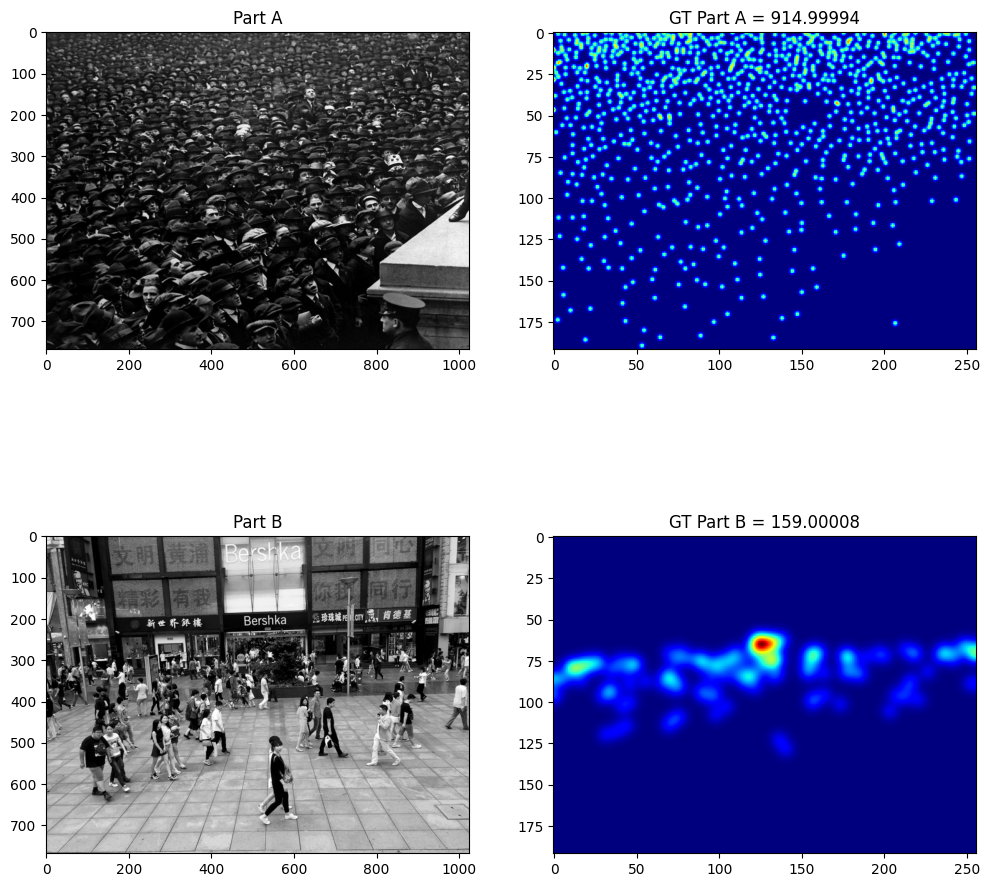

In [45]:
number1 = random.randint(0, 299)
number2 = random.randint(0, 399)

ds = DatasetA(train_A, aug_train)
im, dm = ds[number1]
fs = DatasetB(train_B, aug_train)
im2, dm2 = fs[number2]
f, axarr = plt.subplots(2, 2, figsize=(12, 12))
axarr[0,0].imshow(im, cmap='gray')
axarr[0,1].imshow(dm, cmap='jet')
axarr[1,0].imshow(im2, cmap='gray')
axarr[1,1].imshow(dm2, cmap='jet')
axarr[0,0].title.set_text('Part A')
axarr[0,1].title.set_text('GT Part A = '+str(dm.sum()))
axarr[1,0].title.set_text('Part B')
axarr[1,1].title.set_text('GT Part B = '+str(dm2.sum()))

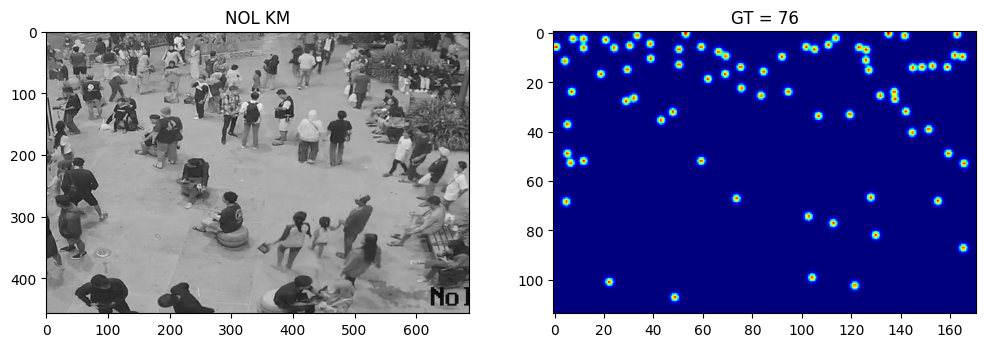

In [47]:
number = random.randint(0, 99)

gs = NOLKM(NOL_KM, aug_val_test)
im, dm = gs[number]

f, axarr = plt.subplots(1, 2, figsize=(12, 12))
axarr[0].imshow(im, cmap='gray')
axarr[0].title.set_text('NOL KM')
axarr[1].imshow(dm, cmap='jet')
axarr[1].title.set_text('GT = '+str(round(dm.sum())))

In [48]:
# Define a function to divide a dataset of images and their corresponding ground truth (GT) into smaller slices
def divide_img(dataset):
    # Initialize empty lists to hold image slices and corresponding ground truth slices
    img = []
    gt = []

    # Loop through each item in the dataset
    # The dataset is assumed to contain pairs of (image, density map)
    for i in range(len(dataset)):
        # Extract the image and corresponding density map (GT)
        im, dm = dataset[i]
        
        # Get the dimensions of the image (height and width)
        height = im.shape[0]
        width = im.shape[1]
        
        # Get the dimensions of the density map (GT)
        height_2 = dm.shape[0]
        width_2 = dm.shape[1]
        
        # Define slices to divide the image into four quadrants (top-left, top-right, bottom-left, bottom-right)
        slices_im = [
            (slice(0, height // 2), slice(0, width // 2)),          # Top-left quadrant
            (slice(0, height // 2), slice(width // 2, width)),      # Top-right quadrant
            (slice(height // 2, height), slice(0, width // 2)),     # Bottom-left quadrant
            (slice(height // 2, height), slice(width // 2, width))  # Bottom-right quadrant
        ]
        
        # Define slices to divide the density map (GT) into four quadrants (top-left, top-right, bottom-left, bottom-right)
        slices_dm = [
            (slice(0, height_2 // 2), slice(0, width_2 // 2)),              # Top-left quadrant
            (slice(0, height_2 // 2), slice(width_2 // 2, width_2)),        # Top-right quadrant
            (slice(height_2 // 2, height_2), slice(0, width_2 // 2)),       # Bottom-left quadrant
            (slice(height_2 // 2, height_2), slice(width_2 // 2, width_2))  # Bottom-right quadrant
        ]
        
        # Loop through each slice in the image (slices_im)
        # For each slice, extract the corresponding piece of the image and append to the 'img' list
        for j, (row_slice, col_slice) in enumerate(slices_im):
            piece = im[row_slice, col_slice]  # Extract the image slice using the defined row and column slices
            img.append(piece)  # Append the slice to the image list
            
        # Loop through each slice in the density map (slices_dm)
        # For each slice, extract the corresponding piece of the density map (GT) and append to the 'gt' list
        for j, (row_slice, col_slice) in enumerate(slices_dm):
            piece = dm[row_slice, col_slice]  # Extract the density map slice using the defined row and column slices
            gt.append(piece)  # Append the slice to the ground truth list
            
    # Return the lists containing the image slices and corresponding ground truth slices
    return img, gt


In [49]:
IMG_part_A = []
GT_part_A = []
ds = DatasetA(train_A, aug_train)

IMG_part_A, GT_part_A = divide_img(ds)

In [50]:
len(IMG_part_A), len(GT_part_A)

(1200, 1200)

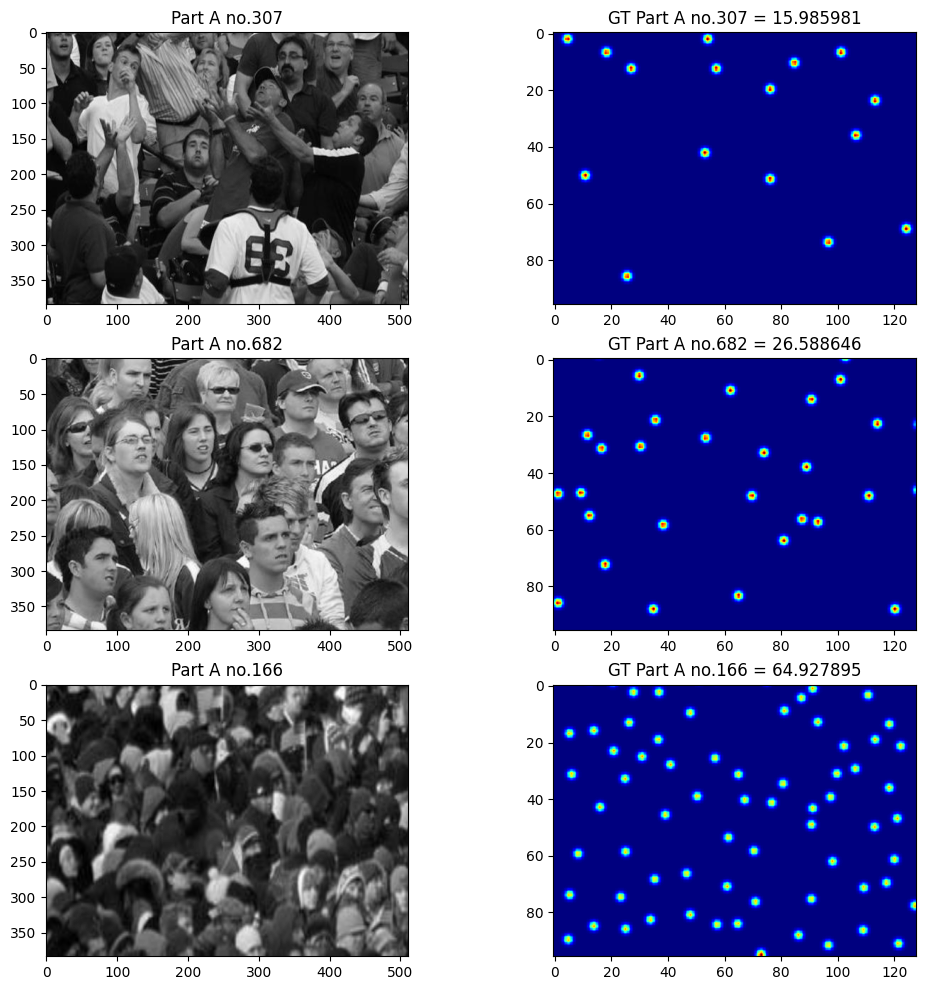

In [51]:
number1 = random.randint(0, 1199)
number2 = random.randint(0, 1199)
number3 = random.randint(0, 1199)

f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(IMG_part_A[number1], cmap='gray')
axarr[0,1].imshow(GT_part_A[number1], cmap='jet')
axarr[1,0].imshow(IMG_part_A[number2], cmap='gray')
axarr[1,1].imshow(GT_part_A[number2], cmap='jet')
axarr[2,0].imshow(IMG_part_A[number3], cmap='gray')
axarr[2,1].imshow(GT_part_A[number3], cmap='jet')
axarr[0,0].title.set_text('Part A no.'+str(number1))
axarr[0,1].title.set_text('GT Part A no.'+str(number1)+' = '+str(GT_part_A[number1].sum()))
axarr[1,0].title.set_text('Part A no.'+str(number2))
axarr[1,1].title.set_text('GT Part A no.'+str(number2)+' = '+str(GT_part_A[number2].sum()))
axarr[2,0].title.set_text('Part A no.'+str(number3))
axarr[2,1].title.set_text('GT Part A no.'+str(number3)+' = '+str(GT_part_A[number3].sum()))

f.savefig("output_plot_part_A.png", dpi=300, bbox_inches='tight')  # Save as PNG
plt.show()

In [52]:
IMG_part_B = []
GT_part_B = []
ds = DatasetB(train_B, aug_train)

IMG_part_B, GT_part_B = divide_img(ds)

In [53]:
len(IMG_part_B), len(GT_part_B)

(1600, 1600)

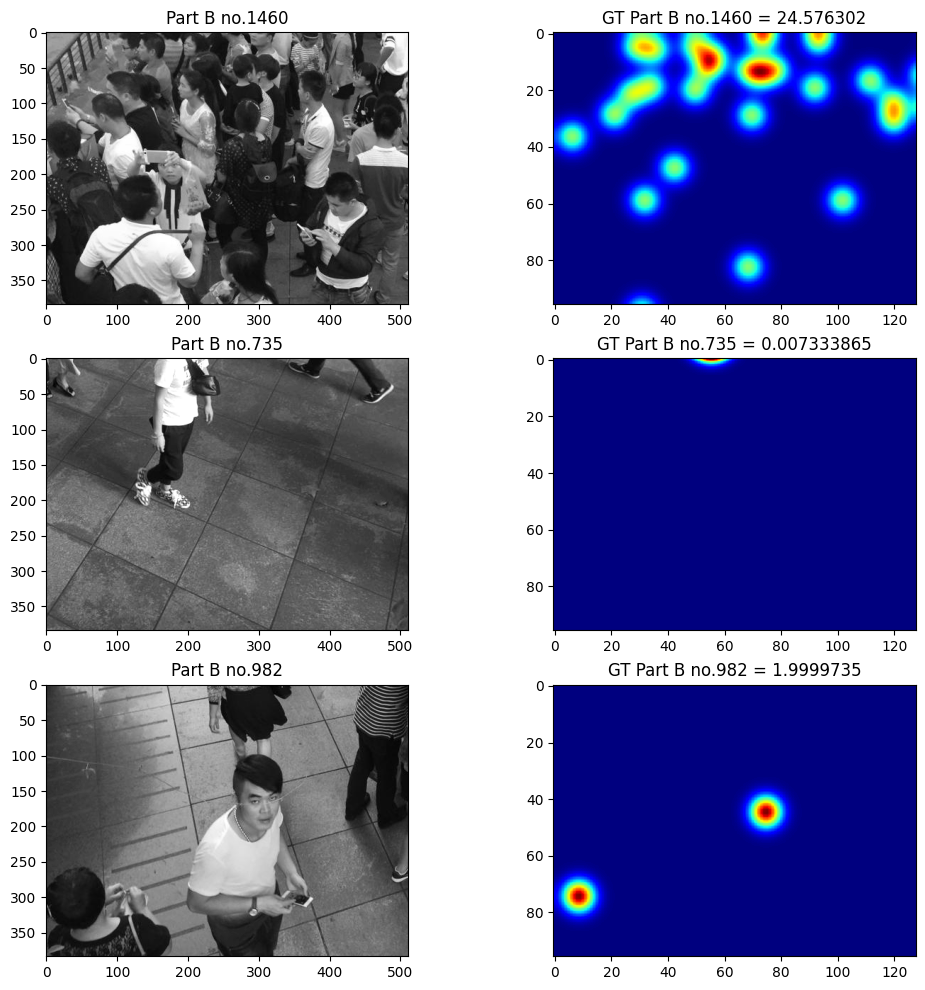

In [54]:
number1 = random.randint(0, 1599)
number2 = random.randint(0, 1599)
number3 = random.randint(0, 1599)

f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(IMG_part_B[number1], cmap='gray')
axarr[0,1].imshow(GT_part_B[number1], cmap='jet')
axarr[1,0].imshow(IMG_part_B[number2], cmap='gray')
axarr[1,1].imshow(GT_part_B[number2], cmap='jet')
axarr[2,0].imshow(IMG_part_B[number3], cmap='gray')
axarr[2,1].imshow(GT_part_B[number3], cmap='jet')
axarr[0,0].title.set_text('Part B no.'+str(number1))
axarr[0,1].title.set_text('GT Part B no.'+str(number1)+' = '+str(GT_part_B[number1].sum()))
axarr[1,0].title.set_text('Part B no.'+str(number2))
axarr[1,1].title.set_text('GT Part B no.'+str(number2)+' = '+str(GT_part_B[number2].sum()))
axarr[2,0].title.set_text('Part B no.'+str(number3))
axarr[2,1].title.set_text('GT Part B no.'+str(number3)+' = '+str(GT_part_B[number3].sum()))

f.savefig("output_plot_part_B.png", dpi=300, bbox_inches='tight')  # Save as PNG
plt.show()

In [55]:
IMG = []
IMG.extend(IMG_part_B)
IMG.extend(IMG_part_A)

GT = []
GT.extend(GT_part_B)
GT.extend(GT_part_A)

In [56]:
IMG_part_A = []
GT_part_A = []
IMG_part_B = []
GT_part_B = []

In [57]:
len(IMG), len(GT)

(2800, 2800)

In [58]:
# Initialize empty lists to store validation images and their corresponding ground truth
IMG_val = []
GT_val = []

qs = DatasetB(valid_B_split, aug_val)
ws = DatasetA(valid_A_split, aug_val)

# Iterate through DatasetB (qs)
for im, dm in qs:
    IMG_val.append(im)  # Append the image (im) to the list IMG_val
    GT_val.append(dm)   # Append the ground truth (dm) to the list GT_val

# Iterate through DatasetA (ws)
for im, dm in ws:
    IMG_val.append(im)  # Append the image (im) to the list IMG_val
    GT_val.append(dm)   # Append the ground truth (dm) to the list GT_val

# Check the lengths
len(IMG_val), len(GT_val)

(449, 449)

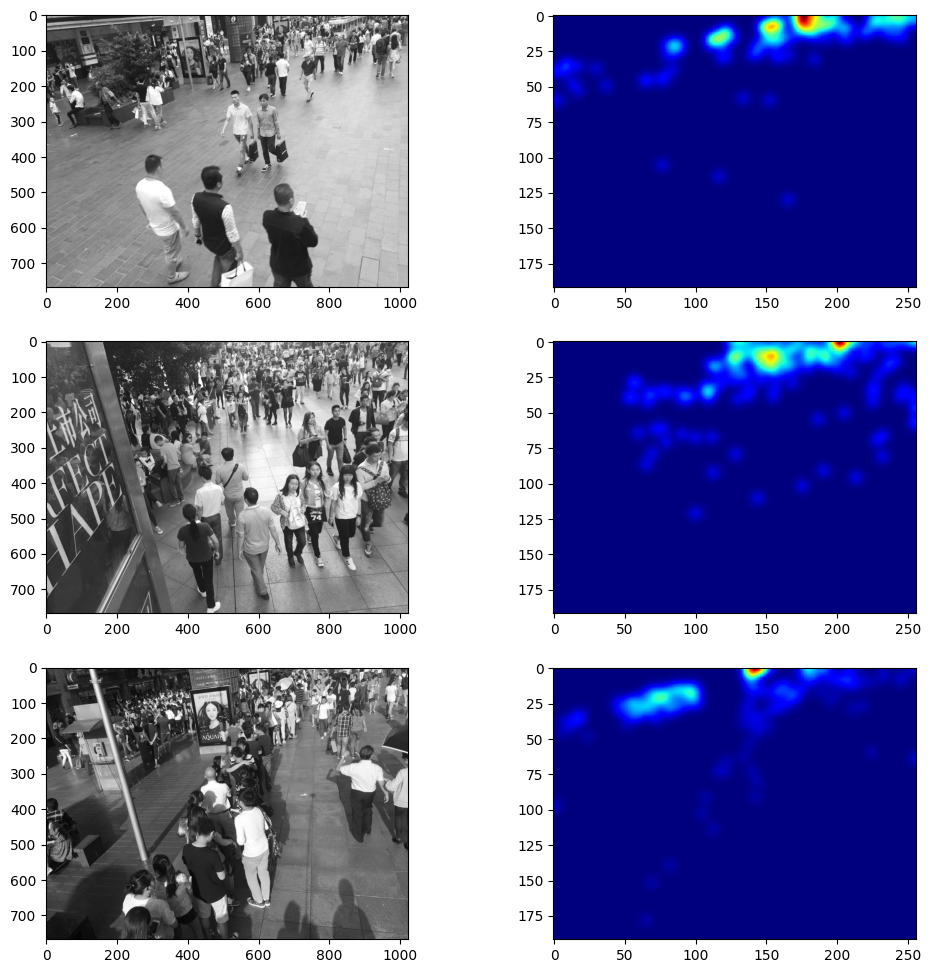

In [59]:
number1 = random.randint(0, 448)
number2 = random.randint(0, 448)
number3 = random.randint(0, 448)

f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(IMG_val[number1], cmap='gray')
axarr[0,1].imshow(GT_val[number1], cmap='jet')
axarr[1,0].imshow(IMG_val[number2], cmap='gray')
axarr[1,1].imshow(GT_val[number2], cmap='jet')
axarr[2,0].imshow(IMG_val[number3], cmap='gray')
axarr[2,1].imshow(GT_val[number3], cmap='jet')

In [ ]:
# Create a TensorFlow dataset from the training images (IMG) and ground truth (GT)
train_loader = tf.data.Dataset.from_tensor_slices((IMG, GT))

# Shuffle the training dataset to randomize the order of the data
# The buffer size is set to the length of the dataset (IMG) to shuffle all elements
train_loader = train_loader.shuffle(buffer_size=len(IMG))

# Batch the training dataset into smaller batches of 32 samples each
train_loader = train_loader.batch(32)

# Prefetch the training data to optimize the input pipeline by loading data in the background
# AUTOTUNE allows TensorFlow to automatically tune the prefetching based on system performance
train_loader = train_loader.prefetch(tf.data.AUTOTUNE)


In [ ]:
# Create a TensorFlow dataset from the validation images (IMG_val) and ground truth (GT_val)
val_loader = tf.data.Dataset.from_tensor_slices((IMG_val, GT_val))

# Batch the validation dataset into smaller batches of 32 samples each
val_loader = val_loader.batch(32)

# Prefetch the validation data to optimize the input pipeline by loading data in the background
val_loader = val_loader.prefetch(tf.data.AUTOTUNE)


In [ ]:
len(train_loader), len(val_loader)

In [ ]:
from keras.layers import Conv2D, MaxPooling2D, Concatenate, Input
from keras.models import Model

def SmallBranch(input):
    small = Conv2D(24, (5, 5), padding='same', activation='relu')(input)
    small = MaxPooling2D(2)(small)
    small = Conv2D(48, (3, 3), padding='same', activation='relu')(small)
    small = MaxPooling2D(2)(small)
    small = Conv2D(24, (3, 3), padding='same', activation='relu')(small)
    small = Conv2D(12, (3, 3), padding='same', activation='relu')(small)
    return small

def MediumBranch(input):
    medium = Conv2D(20, (7, 7), padding='same', activation='relu')(input)
    medium = MaxPooling2D(2)(medium)
    medium = Conv2D(40, (5, 5), padding='same', activation='relu')(medium)
    medium = MaxPooling2D(2)(medium)
    medium = Conv2D(20, (5, 5), padding='same', activation='relu')(medium)
    medium = Conv2D(10, (5, 5), padding='same', activation='relu')(medium)
    return medium

def LargeBranch(input):
    large = Conv2D(16, (9, 9), padding='same', activation='relu')(input)
    large = MaxPooling2D(2)(large)
    large = Conv2D(32, (7, 7), padding='same', activation='relu')(large)
    large = MaxPooling2D(2)(large)
    large = Conv2D(16, (7, 7), padding='same', activation='relu')(large)
    large = Conv2D(8, (7, 7), padding='same', activation='relu')(large)
    return large

def MCNN(input_shape=None):
    # Define the input layer
    input = Input(shape=input_shape)

    # Create branches
    smallbranch = SmallBranch(input)
    mediumbranch = MediumBranch(input)
    largebranch = LargeBranch(input)

    # Concatenate the outputs of all branches
    merged_feature_maps = Concatenate(axis=-1)([largebranch, mediumbranch, smallbranch])

    # Final convolution to produce the density map
    density_map = Conv2D(1, (1, 1), padding='same')(merged_feature_maps)

    # Define the final model
    model = Model(inputs=input, outputs=density_map)
    
    return model


In [ ]:
input_shape  = (None, None, 1)
model  = MCNN(input_shape)
model.summary()

In [ ]:
# Create an Adam optimizer with a specified learning rate of 3e-4
adam = Adam(learning_rate=3e-4)

# Compile the model using the Adam optimizer and mean squared error loss function
model.compile(loss='mean_squared_error', optimizer=adam)

In [ ]:
# Custom callback for logging and saving models
class CSVAndModelSaverCallback(Callback):
    def __init__(self, csv_file, model_save_path, specific_epochs):
        super(CSVAndModelSaverCallback, self).__init__()
        self.csv_file = csv_file
        self.model_save_path = model_save_path
        self.specific_epochs = specific_epochs
        self.best_val_loss = float('inf')
        self.headers_written = False

    def on_epoch_end(self, epoch, logs=None):
        # Extract epoch, loss, and val_loss
        epoch_number = epoch + 1
        loss = logs.get('loss')
        val_loss = logs.get('val_loss')

        # Open CSV file and write data with commas as the delimiter
        with open(self.csv_file, mode='a', newline='') as file:
            writer = csv.writer(file, delimiter=',', quoting=csv.QUOTE_MINIMAL)
            if not self.headers_written:
                writer.writerow(['epoch', 'loss', 'val_loss'])  # Write header only once
                self.headers_written = True
            writer.writerow([epoch_number, loss, val_loss])  # Write data row

        # Save model at specified epochs
        if epoch_number in self.specific_epochs:
            filepath = f"{self.model_save_path}_epoch_{epoch_number}.keras"
            self.model.save(filepath)
            print(f"Model saved at epoch {epoch_number} to {filepath}")

        # Save the model with the lowest validation loss
        if val_loss is not None and val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            filepath = f"{self.model_save_path}_best_val_loss.keras"
            self.model.save(filepath)
            print(f"Model with lowest val_loss ({val_loss}) saved to {filepath}")

# Initialize the callback
csv_and_model_saver = CSVAndModelSaverCallback(
    csv_file='training_log.csv',
    model_save_path='/kaggle/working/MCNN',
    specific_epochs=[50, 150, 250]
)

In [ ]:
# Train the model using the 'fit' method
Pre_Trained_SmallBranch_MCNN_h = model.fit(
    train_loader,  # The training dataset is provided as train_loader 
    
    # The validation dataset is provided as val_loader
    validation_data=val_loader,  
    
    # The model will train for 250 epochs.
    epochs=250,  
    
    # Specify callbacks to be executed during training, such as saving models and logging training progress
    callbacks=[csv_and_model_saver],  
    
    # Set the verbosity level to 1, which prints detailed logs during training
    verbose=1  
)

In [ ]:
# Step 1: Load the CSV file
csv_file = 'training_log.csv'  # Path to your CSV file
data = pd.read_csv(csv_file)

# Step 2: Extract columns
epochs = data['epoch']
loss = data['loss']
val_loss = data['val_loss']

# Step 3: Plot the data
plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')

# Step 4: Add labels, title, legend
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

# Step 5: Show the plot
plt.show()


In [ ]:
# Load the trained models from saved files at different epochs or based on the best validation loss
model_50_epoch = load_model('/kaggle/working/MCNN_epoch_50.keras')
model_150_epoch = load_model('/kaggle/working/MCNN_epoch_150.keras')
model_250_epoch = load_model('/kaggle/working/MCNN_epoch_250.keras')
model_best_val_loss = load_model('/kaggle/working/MCNN_best_val_loss.keras')

In [60]:
# Load the trained models from saved files at different epochs or based on the best validation loss
model_50_epoch = load_model('/kaggle/input/output-mcnn/MCNN_epoch_50.keras')
model_150_epoch = load_model('/kaggle/input/output-mcnn/MCNN_epoch_150.keras')
model_250_epoch = load_model('/kaggle/input/output-mcnn/MCNN_epoch_250.keras')
model_best_val_loss = load_model('/kaggle/input/output-mcnn/MCNN_best_val_loss.keras')

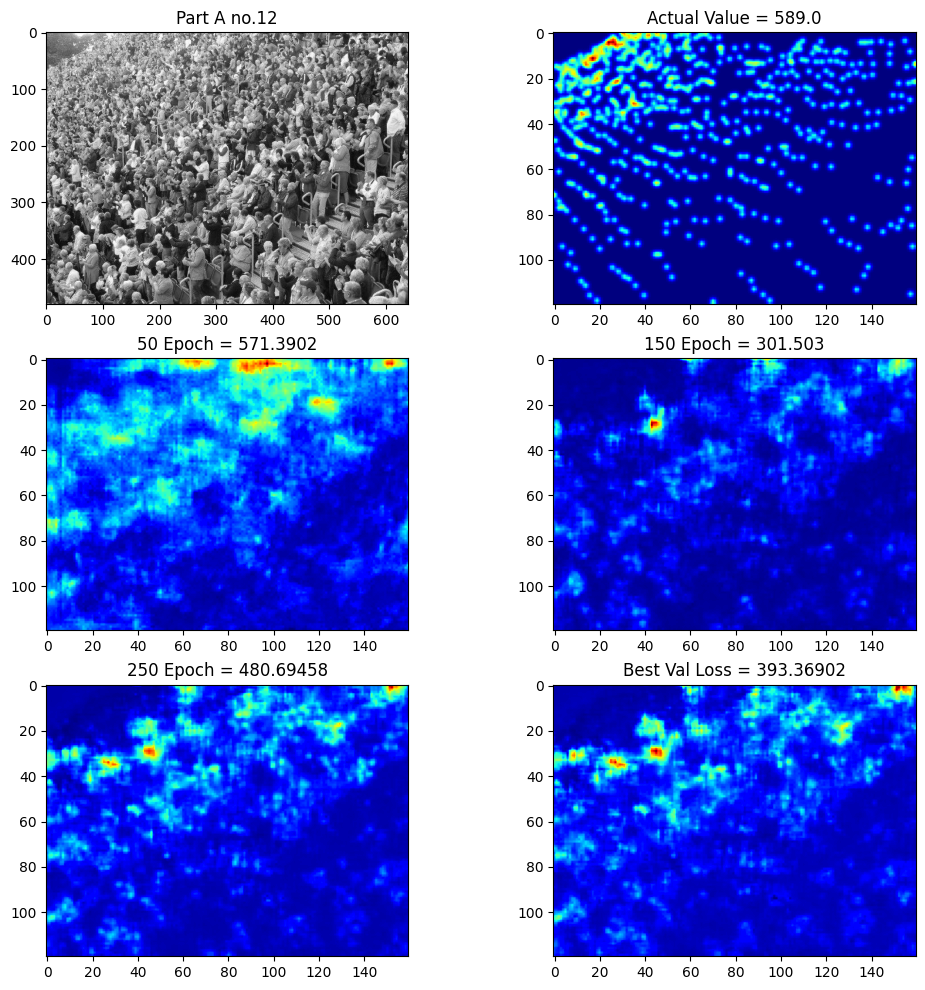

In [61]:
number = random.randint(0, 17)

ds = DatasetA(test_A_split, aug_val_test)

im, dm = ds[number]
test_50_epoch = tf.identity(model_50_epoch(tf.expand_dims(im, axis=0)))[0]
test_150_epoch = tf.identity(model_150_epoch(tf.expand_dims(im, axis=0)))[0]
test_250_epoch = tf.identity(model_250_epoch(tf.expand_dims(im, axis=0)))[0]
test_best_val_loss = tf.identity(model_best_val_loss(tf.expand_dims(im, axis=0)))[0]



f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(im, cmap='gray')
axarr[0,1].imshow(dm, cmap='jet')
axarr[1,0].imshow(test_50_epoch, cmap='jet')
axarr[1,1].imshow(test_150_epoch, cmap='jet')
axarr[2,0].imshow(test_250_epoch, cmap='jet')
axarr[2,1].imshow(test_best_val_loss, cmap='jet')
axarr[0,0].title.set_text('Part A no.'+str(number))
axarr[0,1].title.set_text('Actual Value = '+str(dm.sum()))
axarr[1,0].title.set_text('50 Epoch = '+str(np.sum(test_50_epoch)))
axarr[1,1].title.set_text('150 Epoch = '+str(np.sum(test_150_epoch)))
axarr[2,0].title.set_text('250 Epoch = '+str(np.sum(test_250_epoch)))
axarr[2,1].title.set_text('Best Val Loss = '+str(np.sum(test_best_val_loss)))


In [62]:
epoch_50 = []
epoch_150 = []
epoch_250 = []
best_val_loss = []

gtval = []

ds = DatasetA(test_A_split, aug_val_test)

for im, dm in ds:
    # Predict and sum values
    predval_50 = model_50_epoch(tf.expand_dims(im, axis=0))[0]
    predval_150 = model_150_epoch(tf.expand_dims(im, axis=0))[0]
    predval_250 = model_250_epoch(tf.expand_dims(im, axis=0))[0]
    predval_best_val_loss = model_best_val_loss(tf.expand_dims(im, axis=0))[0]
    epoch_50.append(tf.reduce_sum(predval_50).numpy())
    epoch_150.append(tf.reduce_sum(predval_150).numpy())
    epoch_250.append(tf.reduce_sum(predval_250).numpy())
    best_val_loss.append(tf.reduce_sum(predval_best_val_loss).numpy())
    gtval.append(tf.reduce_sum(dm).numpy())

# Calculate MAE
mae_50 = np.abs(np.subtract(gtval, epoch_50)).mean()
mae_150 = np.abs(np.subtract(gtval, epoch_150)).mean()
mae_250 = np.abs(np.subtract(gtval, epoch_250)).mean()
mae_best_val_loss = np.abs(np.subtract(gtval, best_val_loss)).mean()

# Calculate RMSE
rmse_50 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_50))))
rmse_150 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_150))))
rmse_250 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_250))))
rmse_best_val_loss = np.sqrt(np.mean(np.square(np.subtract(gtval, best_val_loss))))

# Print results with proper formatting
print(f"PART A MAE 50 EPOCH: {mae_50:.5f}")
print(f"PART A MAE 150 EPOCH: {mae_150:.5f}")
print(f"PART A MAE 250 EPOCH: {mae_250:.5f}")
print(f"PART A MAE BEST VAL LOSS: {mae_best_val_loss:.5f}\n")

print(f"PART A RMSE 50 EPOCH: {rmse_50:.5f}")
print(f"PART A RMSE 150 EPOCH: {rmse_150:.5f}")
print(f"PART A RMSE 250 EPOCH: {rmse_250:.5f}")
print(f"PART A RMSE BEST VAL LOSS: {rmse_best_val_loss:.5f}")


PART A MAE 50 EPOCH: 172.90706
PART A MAE 150 EPOCH: 112.55158
PART A MAE 250 EPOCH: 116.02100
PART A MAE BEST VAL LOSS: 109.77345

PART A RMSE 50 EPOCH: 224.34770
PART A RMSE 150 EPOCH: 147.81096
PART A RMSE 250 EPOCH: 163.97827
PART A RMSE BEST VAL LOSS: 152.26602


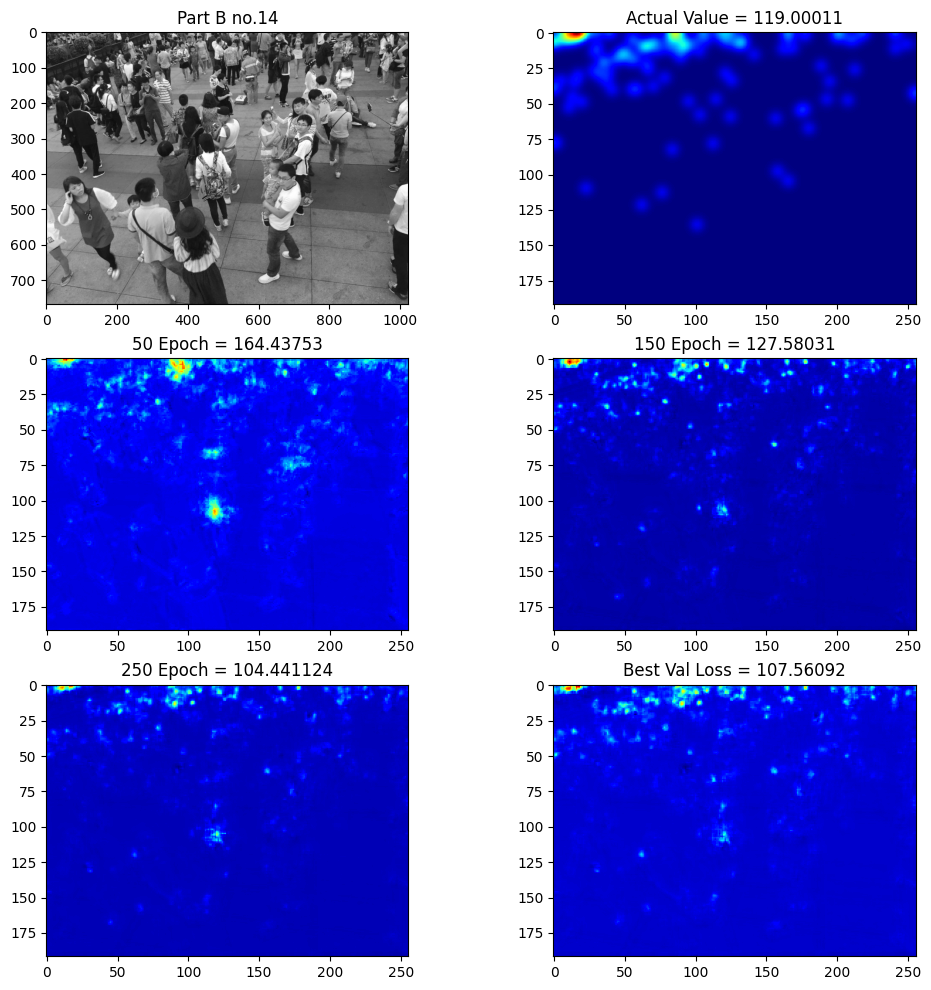

In [63]:
number = random.randint(0, 30)

ds = DatasetB(test_B_split, aug_val_test)

im, dm = ds[number]
test_50_epoch = tf.identity(model_50_epoch(tf.expand_dims(im, axis=0)))[0]
test_150_epoch = tf.identity(model_150_epoch(tf.expand_dims(im, axis=0)))[0]
test_250_epoch = tf.identity(model_250_epoch(tf.expand_dims(im, axis=0)))[0]
test_best_val_loss = tf.identity(model_best_val_loss(tf.expand_dims(im, axis=0)))[0]



f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(im, cmap='gray')
axarr[0,1].imshow(dm, cmap='jet')
axarr[1,0].imshow(test_50_epoch, cmap='jet')
axarr[1,1].imshow(test_150_epoch, cmap='jet')
axarr[2,0].imshow(test_250_epoch, cmap='jet')
axarr[2,1].imshow(test_best_val_loss, cmap='jet')
axarr[0,0].title.set_text('Part B no.'+str(number))
axarr[0,1].title.set_text('Actual Value = '+str(np.sum(dm)))
axarr[1,0].title.set_text('50 Epoch = '+str(np.sum(test_50_epoch)))
axarr[1,1].title.set_text('150 Epoch = '+str(np.sum(test_150_epoch)))
axarr[2,0].title.set_text('250 Epoch = '+str(np.sum(test_250_epoch)))
axarr[2,1].title.set_text('Best Val Loss = '+str(np.sum(test_best_val_loss)))


In [64]:
epoch_50 = []
epoch_150 = []
epoch_250 = []
best_val_loss = []

gtval = []

ds = DatasetB(test_B_split, aug_val_test)

for im, dm in ds:
    # Predict and sum values
    predval_50 = model_50_epoch(tf.expand_dims(im, axis=0))[0]
    predval_150 = model_150_epoch(tf.expand_dims(im, axis=0))[0]
    predval_250 = model_250_epoch(tf.expand_dims(im, axis=0))[0]
    predval_best_val_loss = model_best_val_loss(tf.expand_dims(im, axis=0))[0]
    epoch_50.append(tf.reduce_sum(predval_50).numpy())
    epoch_150.append(tf.reduce_sum(predval_150).numpy())
    epoch_250.append(tf.reduce_sum(predval_250).numpy())
    best_val_loss.append(tf.reduce_sum(predval_best_val_loss).numpy())
    gtval.append(tf.reduce_sum(dm).numpy())

# Calculate MAE
mae_50 = np.abs(np.subtract(gtval, epoch_50)).mean()
mae_150 = np.abs(np.subtract(gtval, epoch_150)).mean()
mae_250 = np.abs(np.subtract(gtval, epoch_250)).mean()
mae_best_val_loss = np.abs(np.subtract(gtval, best_val_loss)).mean()

# Calculate RMSE
rmse_50 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_50))))
rmse_150 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_150))))
rmse_250 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_250))))
rmse_best_val_loss = np.sqrt(np.mean(np.square(np.subtract(gtval, best_val_loss))))

# Print results with proper formatting
print(f"PART B MAE 50 EPOCH: {mae_50:.5f}")
print(f"PART B MAE 150 EPOCH: {mae_150:.5f}")
print(f"PART B MAE 250 EPOCH: {mae_250:.5f}")
print(f"PART B MAE BEST VAL LOSS: {mae_best_val_loss:.5f}\n")

print(f"PART B RMSE 50 EPOCH: {rmse_50:.5f}")
print(f"PART B RMSE 150 EPOCH: {rmse_150:.5f}")
print(f"PART B RMSE 250 EPOCH: {rmse_250:.5f}")
print(f"PART B RMSE BEST VAL LOSS: {rmse_best_val_loss:.5f}")

PART B MAE 50 EPOCH: 68.45699
PART B MAE 150 EPOCH: 38.53639
PART B MAE 250 EPOCH: 26.47827
PART B MAE BEST VAL LOSS: 26.94425

PART B RMSE 50 EPOCH: 79.96736
PART B RMSE 150 EPOCH: 46.03989
PART B RMSE 250 EPOCH: 33.87448
PART B RMSE BEST VAL LOSS: 32.15514


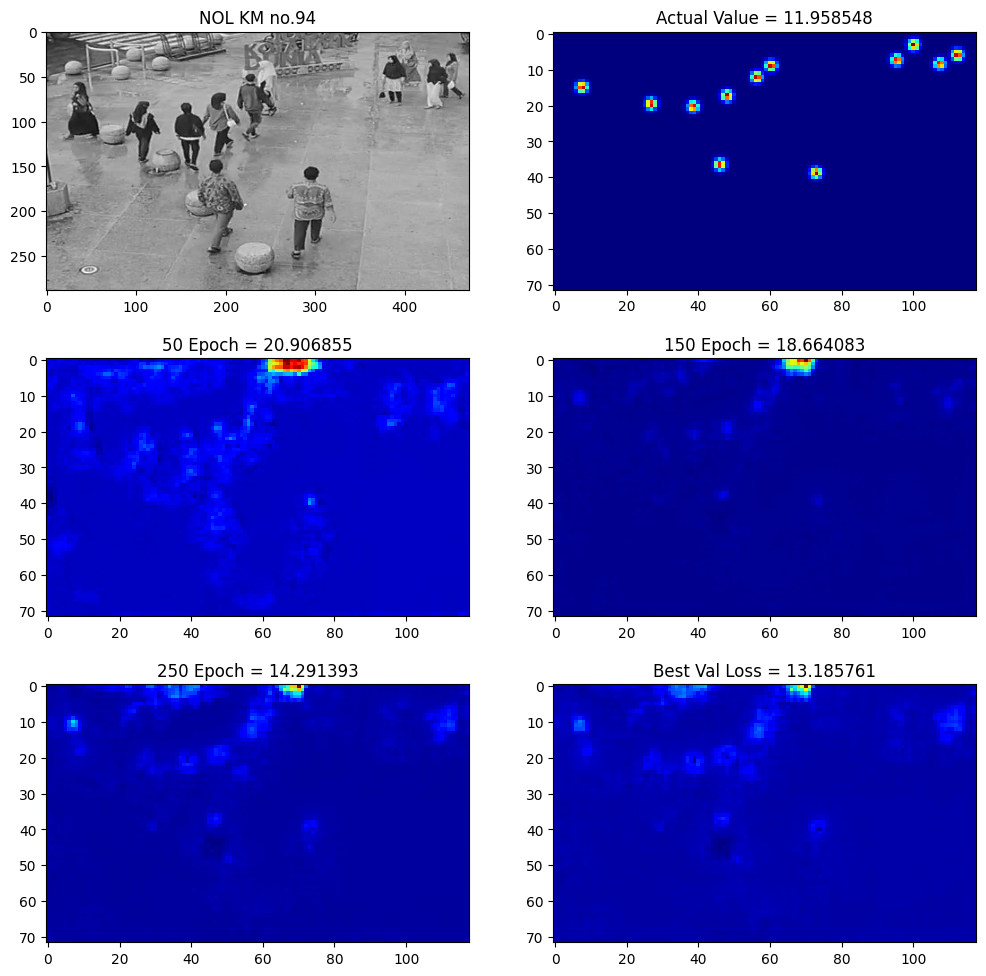

In [48]:
number = random.randint(0, 99)

ds = NOLKM(NOL_KM, aug_val_test)

im, dm = ds[number]
test_50_epoch = tf.identity(model_50_epoch(tf.expand_dims(im, axis=0)))[0]
test_150_epoch = tf.identity(model_150_epoch(tf.expand_dims(im, axis=0)))[0]
test_250_epoch = tf.identity(model_250_epoch(tf.expand_dims(im, axis=0)))[0]
test_best_val_loss = tf.identity(model_best_val_loss(tf.expand_dims(im, axis=0)))[0]

f, axarr = plt.subplots(3, 2, figsize=(12, 12))
axarr[0,0].imshow(im, cmap='gray')
axarr[0,1].imshow(dm, cmap='jet')
axarr[1,0].imshow(test_50_epoch, cmap='jet')
axarr[1,1].imshow(test_150_epoch, cmap='jet')
axarr[2,0].imshow(test_250_epoch, cmap='jet')
axarr[2,1].imshow(test_best_val_loss, cmap='jet')
axarr[0,0].title.set_text('NOL KM no.'+str(number))
axarr[0,1].title.set_text('Actual Value = '+str(dm.sum()))
axarr[1,0].title.set_text('50 Epoch = '+str(np.sum(test_50_epoch)))
axarr[1,1].title.set_text('150 Epoch = '+str(np.sum(test_150_epoch)))
axarr[2,0].title.set_text('250 Epoch = '+str(np.sum(test_250_epoch)))
axarr[2,1].title.set_text('Best Val Loss = '+str(np.sum(test_best_val_loss)))


In [70]:
epoch_50 = []
epoch_150 = []
epoch_250 = []
best_val_loss = []

gtval = []

n = 100

ds = NOLKM(NOL_KM, aug_val_test)

for i, (im, dm) in enumerate (ds):
    if i >= n:
        break
    # Predict and sum values
    predval_50 = model_50_epoch(tf.expand_dims(im, axis=0))[0]
    predval_150 = model_150_epoch(tf.expand_dims(im, axis=0))[0]
    predval_250 = model_250_epoch(tf.expand_dims(im, axis=0))[0]
    predval_best_val_loss = model_best_val_loss(tf.expand_dims(im, axis=0))[0]
    epoch_50.append(tf.reduce_sum(predval_50).numpy())
    epoch_150.append(tf.reduce_sum(predval_150).numpy())
    epoch_250.append(tf.reduce_sum(predval_250).numpy())
    best_val_loss.append(tf.reduce_sum(predval_best_val_loss).numpy())
    gtval.append(tf.reduce_sum(dm).numpy())

# Calculate MAE
mae_50 = np.abs(np.subtract(gtval, epoch_50)).mean()
mae_150 = np.abs(np.subtract(gtval, epoch_150)).mean()
mae_250 = np.abs(np.subtract(gtval, epoch_250)).mean()
mae_best_val_loss = np.abs(np.subtract(gtval, best_val_loss)).mean()

# Calculate RMSE
rmse_50 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_50))))
rmse_150 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_150))))
rmse_250 = np.sqrt(np.mean(np.square(np.subtract(gtval, epoch_250))))
rmse_best_val_loss = np.sqrt(np.mean(np.square(np.subtract(gtval, best_val_loss))))

print(f"IMAGES: {n}")
# Print results with proper formatting
print(f"NOL KM MAE 50 EPOCH: {mae_50:.5f}")
print(f"NOL KM MAE 150 EPOCH: {mae_150:.5f}")
print(f"NOL KM MAE 250 EPOCH: {mae_250:.5f}")
print(f"NOL KM MAE BEST VAL LOSS: {mae_best_val_loss:.5f}\n")

print(f"NOL KM RMSE 50 EPOCH: {rmse_50:.5f}")
print(f"NOL KM RMSE 150 EPOCH: {rmse_150:.5f}")
print(f"NOL KM RMSE 250 EPOCH: {rmse_250:.5f}")
print(f"NOL KM RMSE BEST VAL LOSS: {rmse_best_val_loss:.5f}")

IMAGES: 100
NOL KM MAE 50 EPOCH: 11.01427
NOL KM MAE 150 EPOCH: 7.60624
NOL KM MAE 250 EPOCH: 8.59102
NOL KM MAE BEST VAL LOSS: 7.86995

NOL KM RMSE 50 EPOCH: 16.33704
NOL KM RMSE 150 EPOCH: 10.41229
NOL KM RMSE 250 EPOCH: 11.71883
NOL KM RMSE BEST VAL LOSS: 10.20521
